In [1]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #                         
#     Maurice F. Huguenin, m.huguenin-virchaux@unsw.edu.au, 26. 01. 2024      #                                                
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #
# % preamble ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #                         
base = '/g/data/e14/mv7494/access-om2/archive/025deg_jra55_iaf/'
save = '/gxfs_home/geomar/smomw723/EddiesHC_figures/'

import xarray as xr # for working with labelled multi-dimensional arrays                                                                
import numpy as np # for numerical operations                                                           
import string # for subplot annotation
import matplotlib.pyplot as plt # for matlab-like plotting                                              
from matplotlib.patches import Rectangle # for shaded rectangle
import cartopy.crs as ccrs # for maps     
from matplotlib import gridspec
import matplotlib as mpl
#from cdo import *
#cdo = Cdo()
import os
import sys
import scipy
import warnings
import cmocean as cm
#from wrf import to_np # conversion to arrays required for arrows on maps    
import tarfile as tf
import io
from scipy.stats import linregress

import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore') # suppress warnings
from matplotlib import ticker
import nc_time_axis
import time
import cftime
import cartopy.mpl.ticker as cticker
import string # for subplot annotation
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


#from dask.distributed import Client
#client = Client(n_workers=16)         # careful: do not run with 48 workers here as it will crash
#client = Client(n_workers=8, threads_per_worker=4)
#client

rotblau = [[0.4 , 0.  , 0.12], [0.47, 0.02, 0.13], [0.62, 0.07, 0.16], [0.66, 0.16, 0.2],
           [0.8 , 0.3 , 0.27], [0.87, 0.44, 0.35], [0.93, 0.58, 0.45], [0.96, 0.7 , 0.58], 
           [0.98, 0.8 , 0.71], [0.98, 0.94, 0.92], [0.93, 0.95, 0.96], [0.85, 0.91, 0.95],
           [0.76, 0.87, 0.93], [0.64, 0.8 , 0.89], [0.49, 0.72, 0.84], [0.34, 0.62, 0.79], 
           [0.23, 0.53, 0.74], [0.16, 0.44, 0.7] , [0.1 ,0.35, 0.6], [0.05, 0.24, 0.45], [0.02, 0.19, 0.38]]

/gxfs_home/geomar/smomw723/miniforge3/envs/py3_std/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Loading in PI-CTRL and historical OHC

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC
CPU times: user 7min 34s, sys: 2min 16s, total: 9min 50s
Wall time: 5min 43s


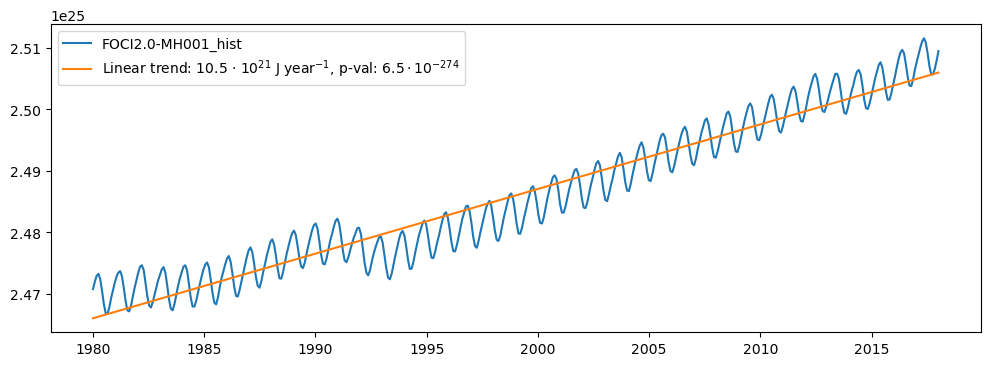

In [2]:
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: 6min 49s for hist
# Wall time: 1h 22min 26s

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC FOCI2.0-MH001_hist
CPU times: user 2min 38s, sys: 46.4 s, total: 3min 24s
Wall time: 1min 57s


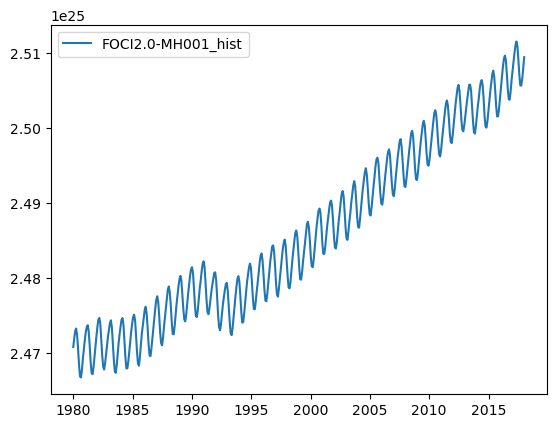

In [5]:
%%time
f = 1
print(exp_names[f], exp_labels[f])
votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])
time = np.linspace(1980,2018,len(OHC_manual.time_counter))
plt.plot(time, OHC_manual, label=exp_labels[f])
plt.legend()

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC FOCI2.0-MH001_hist
CPU times: user 15min 38s, sys: 1min 12s, total: 16min 50s
Wall time: 15min 35s


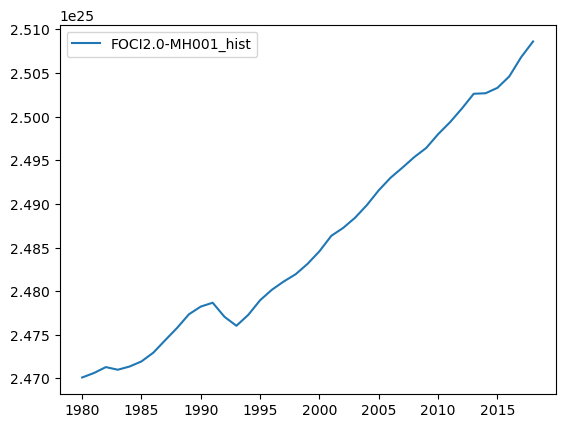

In [6]:
%%time
f = 1
print(exp_names[f], exp_labels[f])
votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])
time = np.linspace(1980,2018,len(OHC_manual.time_counter))
plt.plot(time, OHC_manual, label=exp_labels[f])
plt.legend()

FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets FOCI2.0_MH002_PI-CTRL
CPU times: user 15min 58s, sys: 1min 13s, total: 17min 12s
Wall time: 16min 4s


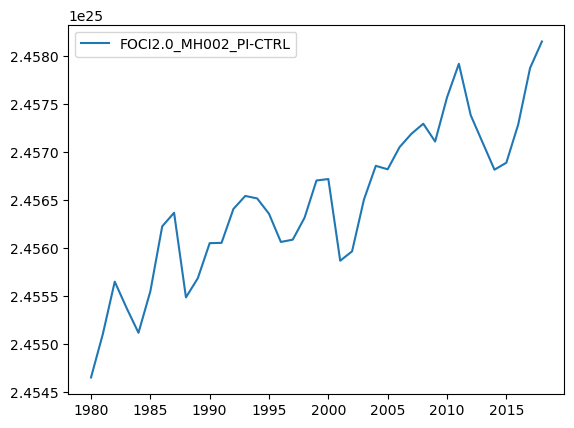

In [7]:
%%time
f = 0
print(exp_names[f], exp_labels[f])
votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])
time = np.linspace(1980,2018,len(OHC_manual.time_counter))
plt.plot(time, OHC_manual, label=exp_labels[f])
plt.legend()

FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets
FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC
CPU times: user 1h 35min 4s, sys: 9min 20s, total: 1h 44min 24s
Wall time: 1h 22min 26s


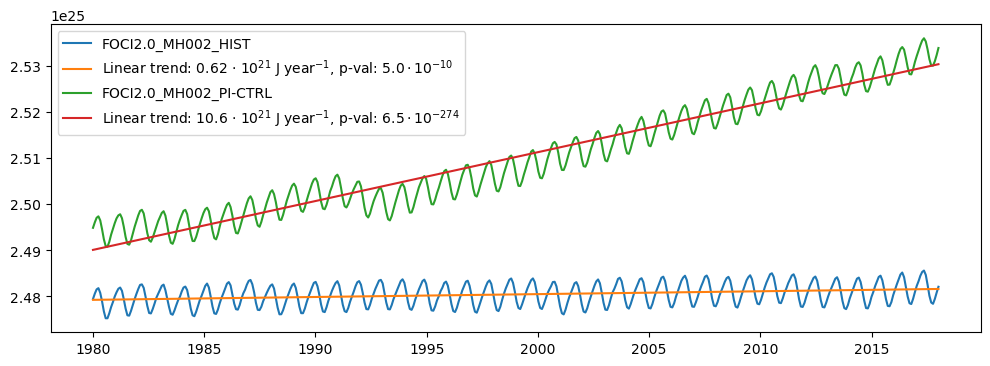

In [11]:
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']


# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [0,1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: 6min 49s for hist
# Wall time: 1h 22min 26s

In [ ]:
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']


base_nemo_pictrl = 'FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets/outdata/nemo/'
base_nemo_hist   = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC/outdata/nemo/'
fn_pictrl        = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 
fn_hist          = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 

fn_OHC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_OHC.nc' 
fn_DIC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_DIC.nc' 

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: Skip to main panel

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC
CPU times: user 10min 9s, sys: 2min 26s, total: 12min 36s
Wall time: 7min 40s


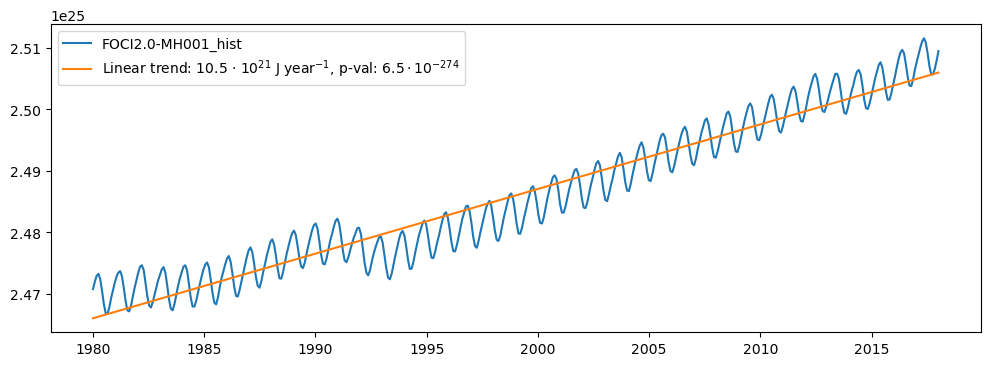

In [19]:
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']


base_nemo_pictrl = 'FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets/outdata/nemo/'
base_nemo_hist   = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC/outdata/nemo/'
fn_pictrl        = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 
fn_hist          = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 

fn_OHC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_OHC.nc' 
fn_DIC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_DIC.nc' 

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [0,1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: 6min 49s for hist
# Wall time: 1h 22min 26s

FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets
FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC
CPU times: user 1h 35min 4s, sys: 9min 20s, total: 1h 44min 24s
Wall time: 1h 22min 26s

<matplotlib.legend.Legend at 0x1505bc83a560>

Selection deleted
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']


base_nemo_pictrl = 'FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets/outdata/nemo/'
base_nemo_hist   = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC/outdata/nemo/'
fn_pictrl        = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 
fn_hist          = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 

fn_OHC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_OHC.nc' 
fn_DIC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_DIC.nc' 

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: 6min 49s for hist
# Wall time: 1h 22min 26s

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC
CPU times: user 10min 9s, sys: 2min 26s, total: 12min 36s
Wall time: 
# Wall time: 1h 22min 26s

### Next step, check yearly data


In [ ]:
%%time
plt.figure(figsize=(12,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']


base_nemo_pictrl = 'FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets/outdata/nemo/ym/'
base_nemo_hist   = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC/outdata/nemo/ym/'

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry

rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

for f in [1]:
    print(exp_names[f])
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).votemper # grid cell pot. temp.
    e3t      = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/ym/' + exp_names[f] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).e3t.squeeze() # grid cell depth
    OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])

    time = np.linspace(1980,2018,len(OHC_manual.time_counter))

    result = linregress(time, OHC_manual)
    # print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
    mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
    z = np.polyfit(time, OHC_manual, 1); poly1 = np.poly1d(z)

    if f == 0: OHC_PICtrl = OHC_manual; poly_PICtrl = poly1
    if f == 1: OHC_hist   = OHC_manual; poly_hist   = poly1

    plt.plot(time, OHC_manual, label=exp_labels[f])
    plt.plot(time, poly1(time), label='Linear trend: '+str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: '+rf"${mantissa} \cdot 10^{{{int(exponent)}}}$")
    
plt.legend()
# Wall time: 6min 49s for hist
# Wall time: 1h 22min 26s

FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC


In [10]:
%%time
a = xr.open_mfdataset(archive + exp_names[0] + '/outdata/nemo/' + exp_names[0] + '*_grid_T.nc', chunks={'time_counter': '200MB'}).groupby('time_counter.year').mean('time_counter').votemper
a.sum(['year', 'y', 'x']).plot()


KeyboardInterrupt



In [2]:
%%time
ts_OHC_hist = (OHC_manual).sum(['deptht', 'y', 'x']).load()
# Wall time: 2min 49s

NameError: name 'OHC_manual' is not defined

slope: 1.060064218405484e+22
p-value: 6.45654600835842e-274
R²: 0.9318300102101394
CPU times: user 14.7 ms, sys: 766 μs, total: 15.4 ms
Wall time: 14.9 ms


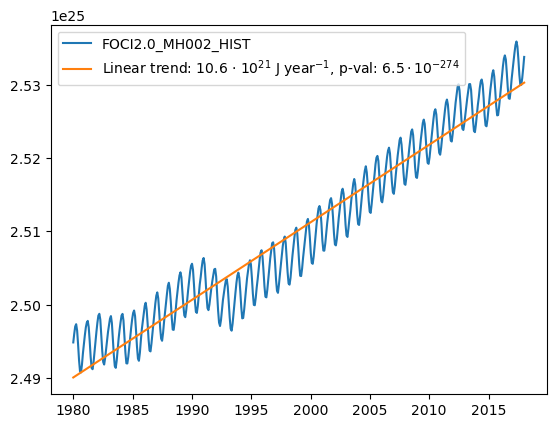

In [76]:
%%time


plt.legend()
# trend value 

In [ ]:
%%time
a = (ds.sheatcnt*area_t)[0,:,:]
b = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht'])[0,:,:]

plt.figure(figsize=(16,4))
plt.subplot(1,3,1); a.plot(levels=np.linspace(-6e20,6e20,21)); plt.title('ds.sheatcnt*area_t')
plt.subplot(1,3,2); b.plot(levels=np.linspace(-6e20,6e20,21)); plt.title('rho_0 * C_p * votemper * area_t * e3t')
plt.subplot(1,3,3); (a-b).plot(levels=np.linspace(-6e18,6e18,21)); plt.title('Difference')

CPU times: user 10min 36s, sys: 1min 55s, total: 12min 31s
Wall time: 8min 51s


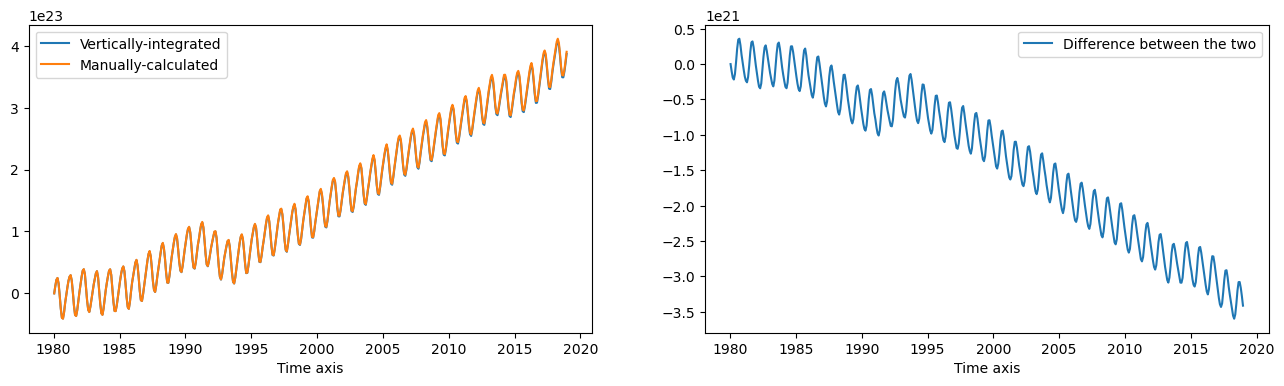

In [2]:
%%time
plt.figure(figsize=(16,4))
#base    = '/gxfs_work/geomar/smomw723/test_20251117_1159_OHC/'
base_nemo = '/gxfs_work/geomar/smomw723/FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC/outdata/nemo/'
fn        = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_T.nc' 
fn_OHC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_*_grid_OHC.nc' 
fn_DIC    = 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC_1m_19800101_19801231_grid_DIC.nc' 

# ocean grid cell area [m2]
area_t = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/mesh_mask.nc')
area_t = (area_t.e1t*area_t.e2t).squeeze()
#area_t.plot(); plt.title('NEMO grid cell area (m$^{2}$)')

# ocean grid cell depth [m]
ht = xr.open_mfdataset('/gxfs_home/geomar/smomw723/EddiesHC_data/bathy_meter__4.2.0_ORCA05.L46.nc').Bathymetry
e3t = xr.open_mfdataset(base_nemo+fn).e3t.squeeze()

rho_0 = 1035.0                       # global ocean average density of sea water   [kg m^{-3}]
C_p   = 3992.10322329649             # global ocean average specific heat capacity [J kg^{-1} K^{-1}]

ds = xr.open_mfdataset(base_nemo+fn).squeeze()
OHC = (ds.sheatcnt*area_t).sum(['y', 'x'])
OHC_base = (OHC - OHC[0])
plt.subplot(1,2,1); OHC_base.plot(label='Vertically-integrated'); plt.title(ds.sheatcnt.long_name + ' (J)')

votemper = xr.open_mfdataset(base_nemo+fn).votemper
OHC_manual = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht', 'y', 'x'])
OHC_manual = (OHC_manual - OHC_manual[0])
plt.subplot(1,2,1); OHC_manual.plot(label='Manually-calculated')
plt.legend()
plt.subplot(1,2,2); (OHC_base - OHC_manual).plot(label='Difference between the two')
plt.legend()
# Wall time: 3min 30 s

CPU times: user 7.52 s, sys: 364 ms, total: 7.89 s
Wall time: 7.17 s


Text(0.5, 1.0, 'Difference')

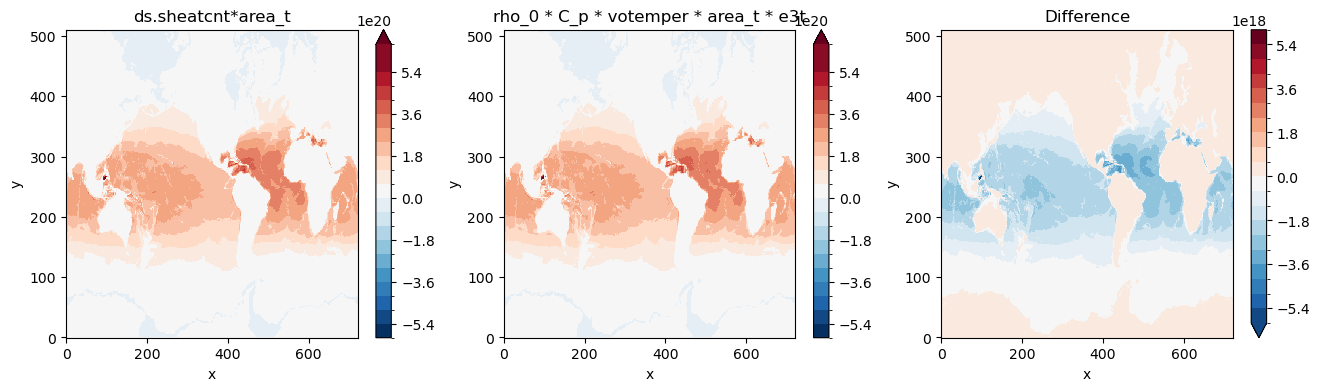

In [3]:
%%time
a = (ds.sheatcnt*area_t)[0,:,:]
b = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht'])[0,:,:]

plt.figure(figsize=(16,4))
plt.subplot(1,3,1); a.plot(levels=np.linspace(-6e20,6e20,21)); plt.title('ds.sheatcnt*area_t')
plt.subplot(1,3,2); b.plot(levels=np.linspace(-6e20,6e20,21)); plt.title('rho_0 * C_p * votemper * area_t * e3t')
plt.subplot(1,3,3); (a-b).plot(levels=np.linspace(-6e18,6e18,21)); plt.title('Difference')

### Loading in PI-CTRL and historical OHC

# Next, work on echam postprocessing first and run Lavinia's scripts

In [ ]:
%%time
fit = (rho_0 * C_p * votemper * area_t * e3t).sum(['deptht']).polyfit(dim="time_counter", deg=1)

slope = fit.polyfit_coefficients.sel(degree=1).load() # slope (trend)
#intercept = fit.polyfit_coefficients.sel(degree=0) # intercept
slope

In [ ]:
(ds.sheatcnt * (60*60*24*30.5*3.61e14)).sum(['y', 'x']).plot()

CPU times: user 1.1 s, sys: 628 ms, total: 1.72 s
Wall time: 3.4 s


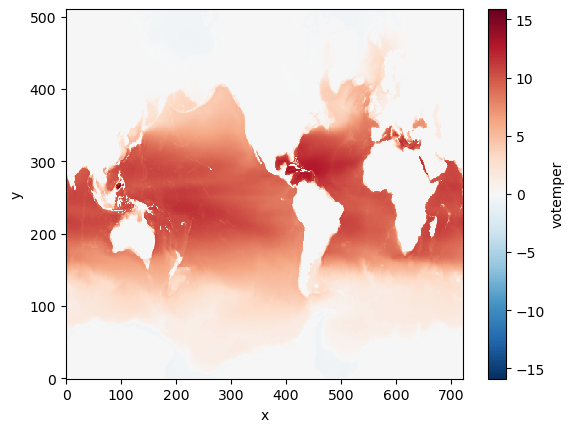

In [8]:
temp_adv = (ds_OHC.ttrd_xad + ds_OHC.ttrd_yad  + ds_OHC.ttrd_zad) # temperature advection
temp.mean(['time_counter', 'deptht']).plot()
# Wall time> 6.24 s

In [24]:
ds.sheatcnt
    

#.mean('time_counter').plot(); plt.title('Vertically-integrated heat content', fontsize=16)

<xarray.DataArray 'sheatcnt' (time_counter: 12, y: 511, x: 722)> Size: 18MB
dask.array<open_dataset-sheatcnt, shape=(12, 511, 722), dtype=float32, chunksize=(1, 511, 722), chunktype=numpy.ndarray>
Coordinates:
    nav_lat        (y, x) float32 1MB dask.array<chunksize=(511, 722), meta=np.ndarray>
    nav_lon        (y, x) float32 1MB dask.array<chunksize=(511, 722), meta=np.ndarray>
    time_centered  (time_counter) datetime64[ns] 96B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 96B 1980-01-16T12:00:00 ... ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:       integral_of_sea_water_potential_temperature_wrt_dept...
    long_name:           Heat content vertically integrated
    units:               J/m2
    online_operation:    average
    interval_operation:  1200 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1200 s)

In [4]:
%%time
# detect coordinate names
lat_name = [c for c in ds.coords if "lat" in c.lower()][0]
lon_name = [c for c in ds.coords if "lon" in c.lower()][0]

lat = ds[lat_name].values
lon = ds[lon_name].values

# 2D mesh or already lat2D/lon2D
if lat.ndim == 1 and lon.ndim == 1:
    lon2d, lat2d = np.meshgrid(lon, lat)
else:
    lon2d, lat2d = lon, lat

z = np.squeeze(ds.values)   # ensure 2-D

# convert lon to -180..180 for Cartopy
if np.nanmax(lon2d) > 180:
    lon2d = ((lon2d + 180) % 360) - 180
    
ticks = np.linspace(0,3,21) # ticks for colour bar

CPU times: user 8.25 ms, sys: 1.05 ms, total: 9.3 ms
Wall time: 8.19 ms


### Plotting routine

Text(0, 1, 'a')

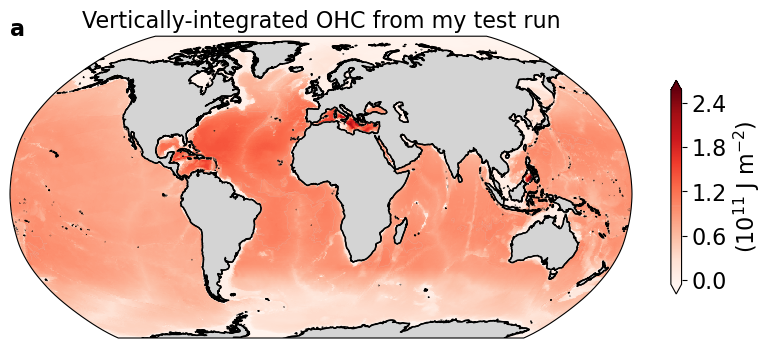

In [5]:
fs = 16
# Create figure and map
fig = plt.figure(figsize=(16,9),tight_layout=True,facecolor='w',edgecolor='k')
gs = gridspec.GridSpec(2, 2, width_ratios = [1,1]) 
ax1 = plt.subplot(gs[0,0], projection=ccrs.Robinson())

# Plot the data
p1 = ax1.pcolormesh(lon, lat, ds.sheatcnt.mean('time_counter')/1e11, transform=ccrs.PlateCarree(), cmap='Reds')
#p1  = sst.plot.contourf(cmap='RdBu_r',levels=ticks,add_colorbar=False,extend='both',transform=ccrs.PlateCarree())
p11 = ax1.contour(lon, lat, ds.sheatcnt[0,:,:]/1e11, levels=[1], linewidths=.1, colors='lightgrey', transform=ccrs.PlateCarree())
#p11 = sst.plot.contour(levels = [0], linewidths=.1, colors='lightgrey', transform=ccrs.PlateCarree())


# Add land, coastlines, etc.
ax1.coastlines(resolution = '50m', linewidth=1) # add coast lines
ax1.add_feature(cfeature.LAND, edgecolor = 'black', facecolor = [.83, .83, .83], zorder = 1)
plt.title('Vertically-integrated OHC from my test run', fontsize=fs)

# add colour bar
cb = plt.colorbar(p1, shrink=.5, orientation='vertical', extend='both'); 
cb.set_label(label='(10$^{11}$ J m$^{-2}$)', size=fs)
cb.ax.tick_params(labelsize=fs); tick_locator = ticker.MaxNLocator(nbins=5)
cb.locator = tick_locator;cb.update_ticks()  
cb.add_lines(p11) # add contours to colour bar

ax1.text(0, 1, string.ascii_lowercase[0], transform=ax1.transAxes, size=16, weight='bold') # bold panel letter at the top left
# Wall time: 8.38 s